In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
import segmentation_models_pytorch as smp

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
# 1. Re-define the exact model architecture
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    classes=2,
    in_channels=3,
    activation=None)

# 2. Load the state dictionary from the .pth file
# checkpoint = torch.load('experiments/excluding-jitter-and-using-256-resolution-and-256-step_20260206_142332/best_model.pth', map_location=torch.device('cuda'))

checkpoint = torch.load('/home/calebe/geo-projects-car/experiments/testando-cel-com-softmax_20260210_171027/best_model.pth', map_location=torch.device('cuda'))
model.load_state_dict(checkpoint['model_state_dict'])

# # Check if the checkpoint contains 'model' or 'state_dict' key
# if 'model' in checkpoint:
#     model.load_state_dict(checkpoint['model'])
# elif 'state_dict' in checkpoint:
#     model.load_state_dict(checkpoint['state_dict'])
# else:
#     model.load_state_dict(checkpoint) # In case it's just the state_dict saved directly

# 3. Set to evaluation mode
model.eval()


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [8]:
image_sat_path = "/data/integracar/amostras_car_orotofoto/ES-3201803-4EB246F91D14462AACC60E101C6310C8.tif"

In [ ]:
from patchify import patchify, unpatchify
class PatchifyInference:
    """
    Classe para fazer inferência em imagens grandes usando patches
    e reconstruir a imagem completa
    """
    def __init__(self, model, device, image_size=1024, patch_size=512, num_classes=2):
        self.model = model
        self.device = device
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.patches_per_row = image_size // patch_size
        
    def predict_image(self, image_path, transform=None):
        """
        Faz predição em uma imagem completa usando patches
        
        Args:
            image_path: Caminho da imagem
            transform: Transformações para aplicar nos patches
            
        Returns:
            prediction: Máscara predita (numpy array)
            probability_map: Mapa de probabilidades (opcional)
        """
        # Carregar imagem
        image = Image.open(image_path).convert('RGB')
        
        # Redimensionar se necessário
        if image.size != (self.image_size, self.image_size):
            image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        
        image_np = np.array(image)
        
        # Dividir em patches
        image_patches = patchify(image_np, (self.patch_size, self.patch_size, 3), step=self.patch_size)
        
        # Preparar array para predições
        pred_patches = np.zeros((
            self.patches_per_row, 
            self.patches_per_row, 
            self.patch_size, 
            self.patch_size
        ), dtype=np.uint8)
        
        # Predizer cada patch
        self.model.eval()
        with torch.no_grad():
            for i in range(self.patches_per_row):
                for j in range(self.patches_per_row):
                    # Extrair patch
                    patch = image_patches[i, j, 0]
                    patch_pil = Image.fromarray(patch.astype('uint8'))
                    
                    # Aplicar transformações
                    if transform:
                        patch_tensor = transform(patch_pil)
                    else:
                        patch_tensor = transforms.ToTensor()(patch_pil)

                    # patch_tensor = transforms.ToTensor()(patch_pil)
                    
                    # Adicionar batch dimension
                    patch_tensor = patch_tensor.unsqueeze(0).to(self.device)
                    
                    # Predição
                    output = self.model(patch_tensor)
                    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

                    # probs = torch.sigmoid(output)
                    # pred = (probs > 0.5).float()
                    # pred = (probs > 0.5).long().squeeze(1)
                    # pred = pred.squeeze(0).squeeze(0).cpu().numpy()
                    
                    # Armazenar predição
                    pred_patches[i, j] = pred
        
        # Reconstruir imagem completa usando unpatchify
        # unpatchify espera (n_patches_h, n_patches_w, patch_h, patch_w)
        reconstructed = unpatchify(pred_patches, (self.image_size, self.image_size))
        
        return reconstructed
    
    def predict_batch(self, image_paths, transform=None, save_dir=None):
        """
        Faz predição em múltiplas imagens
        """
        predictions = []
        
        for img_path in tqdm(image_paths, desc="Predicting images"):
            pred = self.predict_image(img_path, transform)
            predictions.append(pred)
            
            # Salvar se necessário
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                img_name = os.path.basename(img_path)
                save_path = os.path.join(save_dir, img_name)
                Image.fromarray(pred.astype('uint8')).save(save_path)
        
        return predictions


In [31]:
# cv_img_bgr = cv2.imread(image_sat_path)

In [32]:
# image = cv2.imread(image_sat_path)

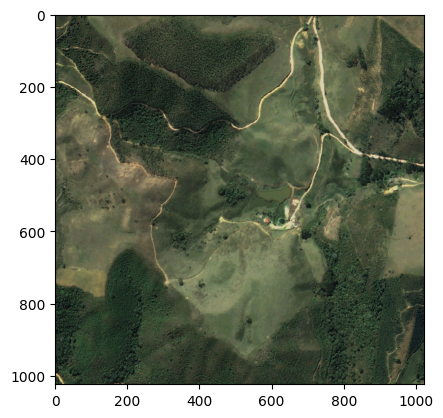

In [4]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_sat_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [31]:
from PIL import Image
image = Image.open(image_sat_path).convert('RGB')

In [ ]:

image_np = np.array(image)

# Dividir em patches
image_patches = patchify(image_np, (512, 512, 3), step=512)

In [33]:
pred_patches = np.zeros((
    2, 
    2, 
    512, 
    512
), dtype=np.uint8)

In [34]:
image_patches[0,0,0]

array([[[ 63,  69,  51],
        [ 63,  69,  51],
        [ 69,  78,  51],
        ...,
        [ 74,  88,  64],
        [ 83,  88,  64],
        [ 83,  88,  64]],

       [[ 61,  72,  49],
        [ 61,  72,  49],
        [ 66,  78,  49],
        ...,
        [ 83,  88,  64],
        [ 83,  88,  64],
        [ 86,  99,  68]],

       [[ 71,  79,  61],
        [ 66,  80,  49],
        [ 72,  80,  49],
        ...,
        [ 83,  89,  64],
        [ 94,  99,  68],
        [ 96, 102,  79]],

       ...,

       [[ 83,  87,  64],
        [ 82,  88,  64],
        [ 93,  99,  79],
        ...,
        [ 27,  32,  28],
        [ 18,  28,  22],
        [ 19,  21,  23]],

       [[ 93,  99,  68],
        [ 98, 103,  79],
        [104,  99,  79],
        ...,
        [ 26,  25,  25],
        [ 19,  18,  22],
        [ 19,  15,  23]],

       [[ 93,  99,  68],
        [ 98, 103,  79],
        [104,  99,  79],
        ...,
        [ 32,  46,  43],
        [ 22,  34,  27],
        [ 29,  36,  31]]

In [35]:
from torchvision import transforms
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [45]:
model.eval()
with torch.no_grad():
    for i in range(2):
        for j in range(2):
            # Extrair patch
            patch = image_patches[i, j, 0]
            if patch.dtype != 'uint8' and patch.max() <= 1.0:
                patch = (patch * 255).astype('uint8')
            else:
                patch = patch.astype('uint8')
                
            patch_pil = Image.fromarray(patch)
            
            # Aplicar transformações
            # patch_tensor = val_transform(patch_pil)
            patch_tensor = transforms.ToTensor()(patch_pil)
            
            # Adicionar batch dimension
            patch_tensor = patch_tensor.unsqueeze(0).to('cpu')
            
            # Predição
            output = model(patch_tensor)
            probs = torch.sigmoid(output)
            pred = (probs > 0.5).float()
            pred = pred.squeeze(0).squeeze(0).cpu().numpy()

            # pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            
            # Armazenar predição
            pred_patches[i, j] = pred

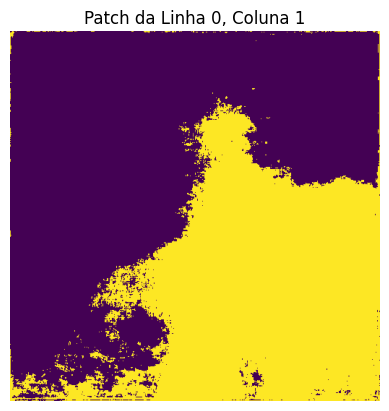

In [39]:
# single_patch = patchprees[0, 1, 0, :, :, :] 

plt.imshow(pred)
plt.title("Patch da Linha 0, Coluna 1")
plt.axis('off')
plt.show()

In [26]:
model.eval() 
patch = image_patches[1, 1, 0]
print(f"Max value no patch original: {patch.max()}")
if patch.dtype != 'uint8' and patch.max() <= 1.0:
    patch = (patch * 255).astype('uint8')
else:
    patch = patch.astype('uint8')
    
patch_pil = Image.fromarray(patch)

# Aplicar transformações
patch_tensor = val_transform(patch_pil)
# patch_tensor = transforms.ToTensor()(patch_pil)

# Adicionar batch dimension
patch_tensor = patch_tensor.unsqueeze(0).to('cpu')

# Predição
output = model(patch_tensor)
# print("Shape da saída:", output.shape) # Deve ser [1, N_CLASSES, H, W]
# print("Valores máximos por classe:", output.max(dim=3)[0].max(dim=2)[0]) 
# pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

probs = torch.sigmoid(output)
pred = (probs > 0.5).float()
pred = pred.squeeze(0).squeeze(0).cpu().numpy()

pred_patches[0, 0] = pred

Max value no patch original: 219


In [27]:
probs

tensor([[[[0.7015, 0.7232, 0.7208,  ..., 0.6363, 0.6541, 0.6406],
          [0.6993, 0.7190, 0.6793,  ..., 0.6562, 0.6867, 0.6573],
          [0.6969, 0.7198, 0.6629,  ..., 0.6587, 0.6715, 0.6475],
          ...,
          [0.6687, 0.7225, 0.7221,  ..., 0.6809, 0.6714, 0.7175],
          [0.6402, 0.6657, 0.6887,  ..., 0.6370, 0.6314, 0.7123],
          [0.6034, 0.6560, 0.6329,  ..., 0.6882, 0.6834, 0.6776]]]],
       grad_fn=<SigmoidBackward0>)

In [53]:
pred_patches

array([[[[1, 1, 1, ..., 0, 1, 0],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 0, 0],
         ...,
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 0, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1]],

        [[1, 0, 0, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 0, ..., 1, 1, 1],
         ...,
         [1, 1, 0, ..., 1, 1, 1],
         [1, 0, 0, ..., 0, 0, 1],
         [1, 1, 1, ..., 1, 1, 1]]],


       [[[1, 1, 0, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 0],
         ...,
         [1, 1, 1, ..., 1, 1, 1],
         [1, 0, 0, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1]],

        [[0, 0, 0, ..., 1, 1, 1],
         [0, 0, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         ...,
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 0, 1, 1],
         [1, 1, 1, ..., 1, 1, 1]]]], dtype=uint8)

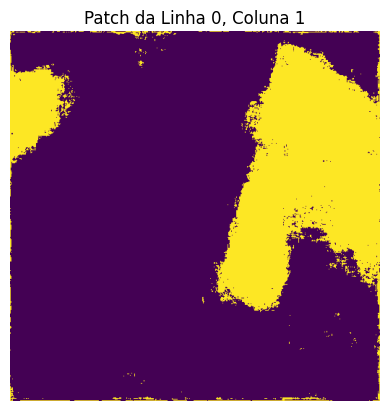

In [51]:
plt.imshow(pred_patches[0,1])
plt.title("Patch da Linha 0, Coluna 1")
plt.axis('off')
plt.show()

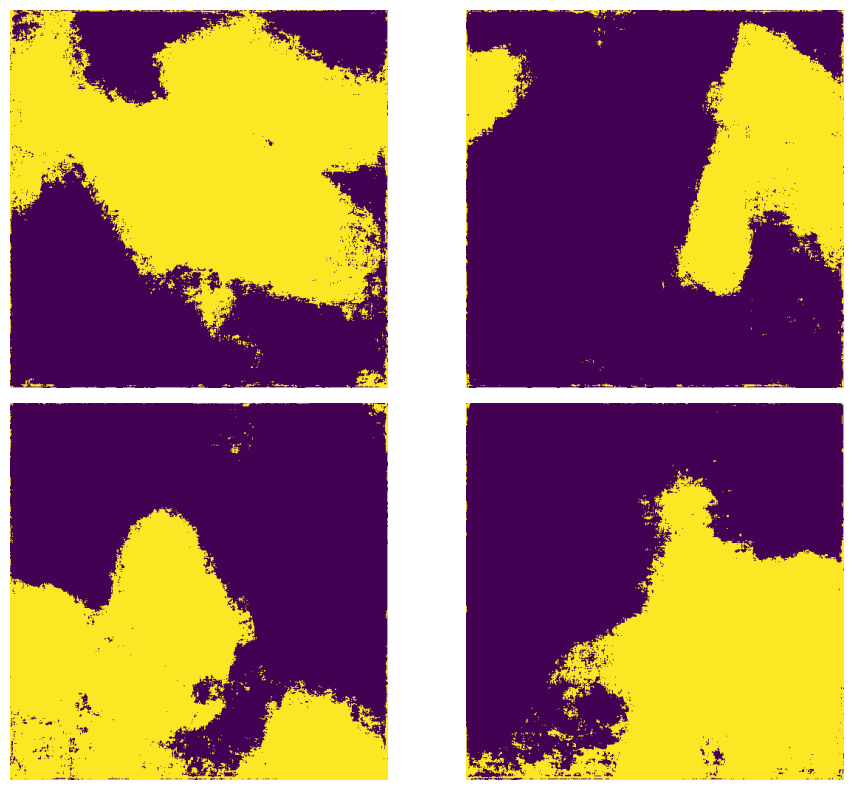

In [56]:
n_rows = pred_patches.shape[0]
n_cols = pred_patches.shape[1]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))

for i in range(n_rows):
    for j in range(n_cols):
        # Extrai o patch [i, j]
        # O index 0 é usado para acessar o conteúdo dentro da dimensão extra criada pelo patchify
        patch_image = pred_patches[i, j]
        
        # Exibe no subplot correspondente
        if n_rows == 1 or n_cols == 1: # Tratamento para caso só tenha 1 linha ou coluna
             ax = axes[max(i, j)]
        else:
             ax = axes[i, j]
             
        ax.imshow(patch_image)
        ax.axis('off') # Remove eixos para limpar o visual

plt.tight_layout()
plt.show()

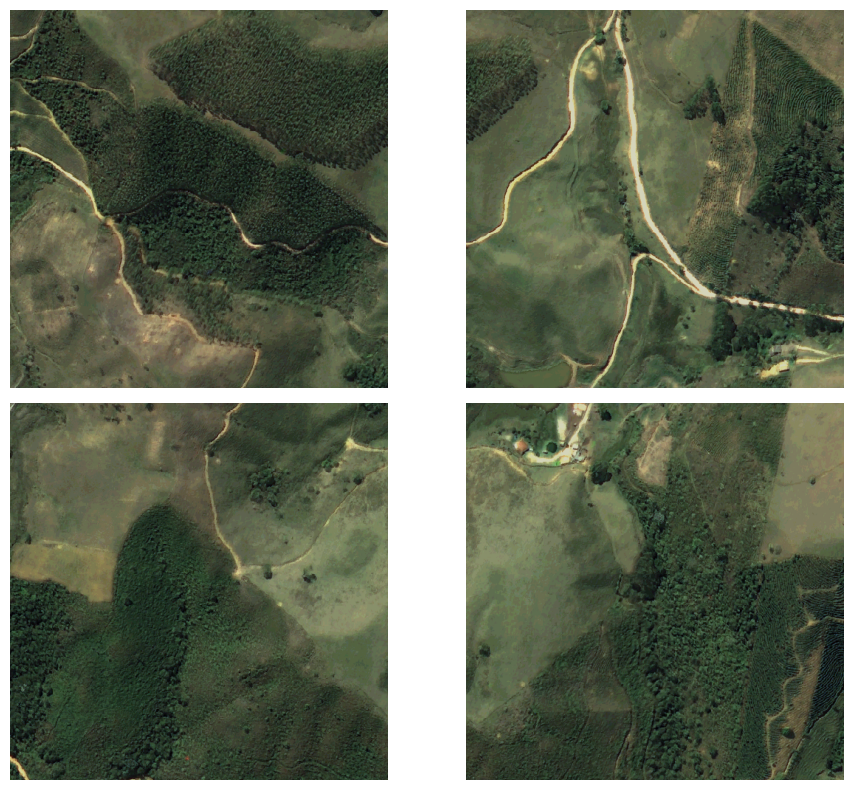

In [57]:
n_rows = image_patches.shape[0]
n_cols = image_patches.shape[1]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))

for i in range(n_rows):
    for j in range(n_cols):
        # Extrai o patch [i, j]
        # O index 0 é usado para acessar o conteúdo dentro da dimensão extra criada pelo patchify
        patch_image = image_patches[i, j, 0, :, :, :]
        
        # Exibe no subplot correspondente
        if n_rows == 1 or n_cols == 1: # Tratamento para caso só tenha 1 linha ou coluna
             ax = axes[max(i, j)]
        else:
             ax = axes[i, j]
             
        ax.imshow(patch_image)
        ax.axis('off') # Remove eixos para limpar o visual

plt.tight_layout()
plt.show()

In [2]:
import torch
import gc

# Assuming 'model', 'optimizer', 'loss_function', and any related data tensors are defined and no longer needed

# 2. Invoke Python's garbage collector to reclaim the memory
gc.collect()

# 3. Clear the PyTorch CUDA cache (if using a GPU)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [10]:
from tqdm import tqdm


In [20]:
patchify_inference = PatchifyInference(
    model=model,
    device=device,
    image_size=1024,
    patch_size=512,
    num_classes=2
)

In [21]:
import os
from src.experiment_logs import ExperimentLogger

In [22]:
logger = ExperimentLogger(
    experiment_name="esse ai",
    config=None,
    use_wandb=False
)
    

📊 Experimento iniciado: esse ai_20260210_174438
📁 Logs salvos em: experiments/esse ai_20260210_174438


In [23]:
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [24]:
from PIL import Image

In [25]:
with open('data-segments/validation_sample.txt', 'r') as f:
        val_images = [line.strip() for line in f.readlines()]
    
    # Fazer predição em algumas imagens de exemplo
predictions_dir = os.path.join("/home/calebe/geo-projects-car/experiments/testando-cel-com-softmax_20260210_171027", "predictions")
os.makedirs(predictions_dir, exist_ok=True)

for img_name in val_images[:3]:  # Testar com 3 imagens
    img_path = os.path.join("/data/integracar/amostras_car_orotofoto/", img_name)
    
    print(f"Predizendo: {img_name}")
    pred_mask = patchify_inference.predict_image(img_path, val_transform)
    
    # Salvar predição
    pred_save_path = os.path.join(predictions_dir, f"pred_{img_name}")
    Image.fromarray(pred_mask.astype('uint8')).save(pred_save_path)
    
    # Criar visualização
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    original = Image.open(img_path)
    gt_mask = Image.open(os.path.join("/data/integracar/amostras_car_mask/", img_name))
    
    axes[0].imshow(original)
    axes[0].set_title('Original (1024x1024)')
    axes[0].axis('off')
    
    axes[1].imshow(gt_mask, cmap='tab20')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    axes[2].imshow(pred_mask, cmap='tab20')
    axes[2].set_title('Prediction (Unpatchified)')
    axes[2].axis('off')
    
    plt.tight_layout()
    logger.log_figure(fig, f'full_image_prediction_{img_name.split(".")[0]}')
    plt.close()

Predizendo: ES-3201605-6D3B7D2F0DA54E37A1DB8D30B9D72C9E.tif


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same